# Compute mutation rates

Import Python modules

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import glob
from collections import defaultdict
import math
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(font_scale=1.0, style='ticks', palette='colorblind')
import scipy
from Bio import SeqIO
from Bio.Seq import Seq

In [2]:
# Show all columns
pd.set_option('display.max_columns', None)

## Read in data giving mutational counts and opportunity

In [3]:
# Function for reading in data
def read_counts(f, segment, subtype, host=None):
    df = pd.read_csv(f, keep_default_na=False, low_memory=False)
    df = df.replace('', np.nan)
    df['subtype'] = subtype
    df['segment'] = segment
    df['segment_subtype'] = df['segment'] + '_' + df['subtype']
    df['segment_length'] = df['site'].max() - df['site'].min()
    if host is not None:
        df['host'] = host
    return df

# Cycle over segments and read in counts data. For each tree, we use:
#  - results/{segment}/{subtype}/mutation_counts.csv for the global ('all' host) tree
#  - results/{segment}/{subtype}/host_stratified/mutation_counts.csv for per-host counts
#    (this file already has a 'host' column from the host-stratified rule)
segments = ['PB2', 'PB1', 'PA', 'HA', 'NP', 'NA', 'NS', 'MP']
dfs = []
for segment in segments:
    subtype_dirs = [d for d in glob.glob(f'../results/{segment}/*') if os.path.isdir(d)]
    for subtype_dir in subtype_dirs:
        subtype = os.path.basename(subtype_dir)

        # Counts from the global tree (all hosts pooled)
        f = os.path.join(subtype_dir, 'mutation_counts.csv')
        dfs.append(read_counts(f, segment, subtype, host='all'))

        # Host-stratified counts (one row per site/mutation/host)
        f = os.path.join(subtype_dir, 'host_stratified', 'mutation_counts.csv')
        dfs.append(read_counts(f, segment, subtype))

counts_df = (
    pd.concat(dfs)
    .rename(columns={'parent_motif':'motif'})
)

# Compute evolutionary opportunities and rates
counts_df['evo_opp'] = counts_df['syn_branch_length'] / counts_df['segment_length']
counts_df['rate'] = counts_df['actual_count'] / counts_df['evo_opp']

# Remove rows with incomplete motifs (e.g. sites near the ends of the segment)
counts_df = counts_df[
    (counts_df['motif'].notnull()) &
    (counts_df['motif'].str.len() == 3)
]

# Flag sites in regions where synonymous rates are not a good neutral reference:
#   (a) known packaging signals (first n3 / last n5 nt of each CDS),
#   (b) canonical splice junctions (MP, NS) within 5 nt of each position, and
#   (c) alternative-frame ORFs that overlap the main CDS (PA-X in PA, nt 572-760).
# These sites are excluded from genome-wide / segment-wide / motif-level aggregations and
# from neutral-model fitting, but retained in site_specific_mutation_rates.csv so per-site
# rates and fitness effects can still be estimated for them.
packaging_signals = pd.read_csv(
    '../data/packaging_signal_boundaries.csv', keep_default_na=False,
)
splice_sites = pd.read_csv(
    '../data/splice_site_boundaries.csv', keep_default_na=False,
)
alt_orfs = pd.read_csv(
    '../data/alternative_orf_boundaries.csv', keep_default_na=False,
)

n3_by_segment = (
    packaging_signals[packaging_signals['end'] == '3prime_vRNA']
    .set_index('segment')['nt'].to_dict()
)
n5_by_segment = (
    packaging_signals[packaging_signals['end'] == '5prime_vRNA']
    .set_index('segment')['nt'].to_dict()
)
_max_site = counts_df.groupby(['segment', 'subtype'])['site'].transform('max')
_n3 = counts_df['segment'].map(n3_by_segment).fillna(0).astype(int)
_n5 = counts_df['segment'].map(n5_by_segment).fillna(0).astype(int)
_in_packaging_signal = (counts_df['site'] <= _n3) | (counts_df['site'] > _max_site - _n5)

splice_window_nt = 5
_near_splice_site = pd.Series(False, index=counts_df.index)
for _, row in splice_sites.iterrows():
    _near_splice_site |= (
        (counts_df['segment'] == row['segment']) &
        ((counts_df['site'] - row['position']).abs() <= splice_window_nt)
    )

_in_alt_orf = pd.Series(False, index=counts_df.index)
for _, row in alt_orfs.iterrows():
    _in_alt_orf |= (
        (counts_df['segment'] == row['segment']) &
        (counts_df['site'] >= row['start']) &
        (counts_df['site'] <= row['end'])
    )

counts_df['exclude_from_mut_rate_analysis'] = (
    _in_packaging_signal | _near_splice_site | _in_alt_orf
)

# Save counts data to a file
counts_df.sort_values('mut_type', inplace=True)
counts_df.to_csv('../results/counts.csv', index=False)

counts_df.head()

,site,nt_mut,wt_nt,mut_nt,gene,codon_position,codon_site,wt_codon,mut_codon,wt_aa,mut_aa,aa_mut,motif,actual_count,branch_length,syn_branch_length,mut_class,mut_type,subtype,segment,segment_subtype,segment_length,host,evo_opp,rate,exclude_from_mut_rate_analysis
82797,1159,A1159C,A,C,PA,1,387,ATT,CTT,I,L,I387L,CAT,0,1385,1067,nonsynonymous,AC,all,PA,PA_all,2148,avian,0.496741,0.000000,False
40255,1162,A1162C,A,C,PA,1,388,AGC,CGC,S,R,S388R,TAG,1,32678,22733,nonsynonymous,AC,all,PA,PA_all,2148,all,10.583333,0.094488,False
40254,1162,A1162C,A,C,PA,1,388,AGC,CGC,S,R,S388R,GAG,0,198,141,nonsynonymous,AC,all,PA,PA_all,2148,all,0.065642,0.000000,False
40253,1162,A1162C,A,C,PA,1,388,AGC,CGC,S,R,S388R,CAG,0,5801,4444,nonsynonymous,AC,all,PA,PA_all,2148,all,2.068901,0.000000,False
40252,1162,A1162C,A,C,PA,1,388,AGC,CGC,S,R,S388R,AAG,2,91033,65332,nonsynonymous,AC,all,PA,PA_all,2148,all,30.415270,0.065756,False


Plot the distribution of evolutionary opportunity for mutations from each segment/subtype tree.

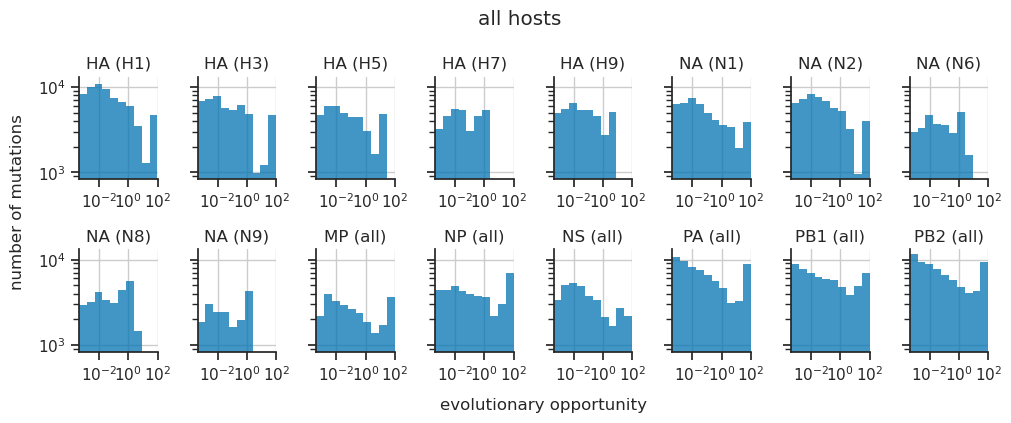

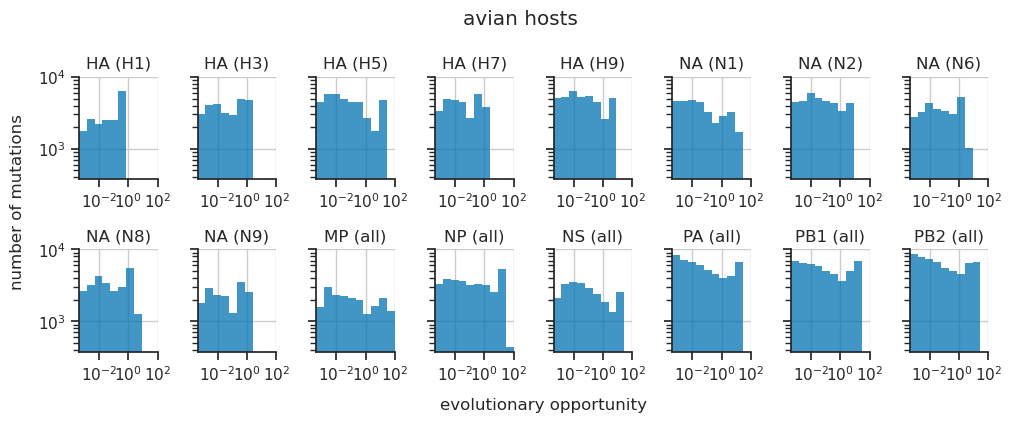

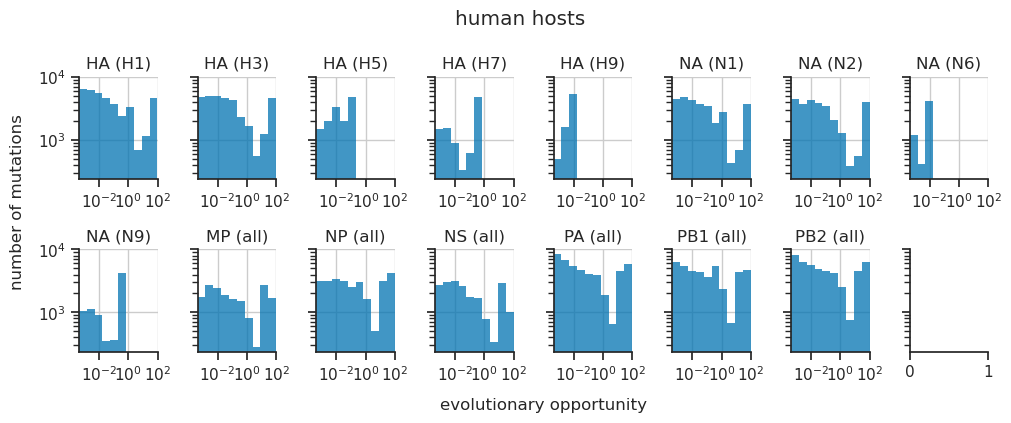

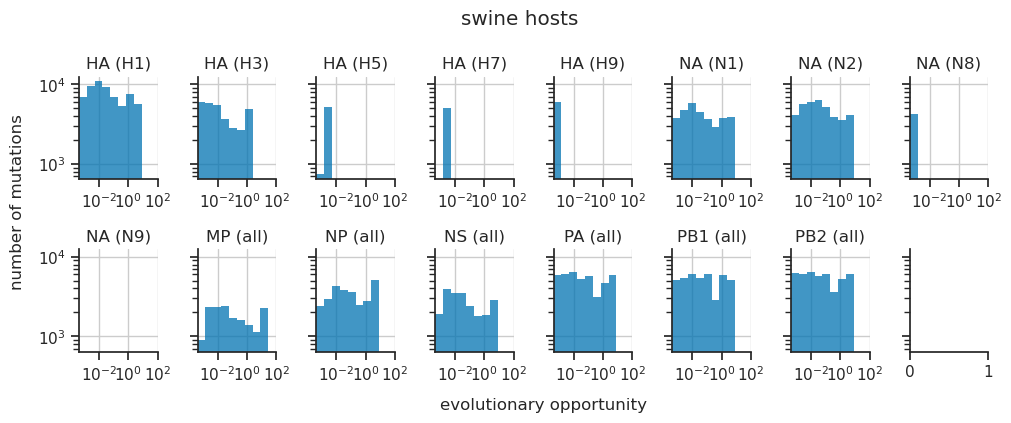

In [4]:
# Define bins
nbins = 10
evo_vals = counts_df['evo_opp']
evo_vals = evo_vals[evo_vals > 0]
bins = np.geomspace(evo_vals.min(), evo_vals.max(), nbins + 1)

# Function for sorting by segment and subtype
def sort_segment_subtype(segment_subtype):
    segment = segment_subtype.split('_')[0]
    if segment == 'HA':
        return (0, segment_subtype)
    elif segment == 'NA':
        return (1, segment_subtype)
    else:
        return (2, segment_subtype)

# Make one plot per host
for (host, host_data) in counts_df.groupby('host'):
    host_data.sort_values('segment_subtype', key=lambda x: x.apply(sort_segment_subtype), inplace=True)
    (fig, axs) = plt.subplots(ncols=8, nrows=2, figsize=[10,4], sharey=True)
    axs = axs.reshape(-1)
    for (i, segment_subtype) in enumerate(host_data['segment_subtype'].unique()):
        subtype_data = host_data[host_data['segment_subtype'] == segment_subtype]
        (segment, subtype) = segment_subtype.split('_')
        if len(subtype_data) == 0:
            continue
        sns.histplot(x='evo_opp', data=subtype_data, ax=axs[i], bins=bins)
        axs[i].set(
            xscale='log', yscale='log', title=f'{segment} ({subtype})',
            ylabel='', xlabel='',
            xlim=(evo_vals.min(), evo_vals.max()),
            xticks=[1e-2, 1e0, 1e2]
        )
        axs[i].grid()

    # Add common y label
    fig.text(-0.01, 0.5, 'number of mutations', va='center', rotation='vertical')
    fig.text(0.42, -0.01, 'evolutionary opportunity', va='center', rotation='horizontal')

    plt.suptitle(f'{host} hosts')

    plt.tight_layout()
    sns.despine()
    plt.show()

## Compute genome-wide mutation rates

Compute genome-wide rates, grouping data across all subtypes. Only analyze mutations with an evolutionary opportunity >0.1, corresponding to 0.1 synonymous mutation count per site in a segment across all branches where a mutation was possible. This focuses on the mutations with the most data (though results do not really change if all mutations are included).

In [5]:
# Compute genome-wide rates for each host category (all, human, avian).
# Exclude sites in packaging signals and near canonical splice junctions (all mutation
# classes) so the numerator and denominator come from the same set of sites and syn/nonsyn
# ratios stay comparable.
genome_wide_evo_opp_threshold = 0.1
genome_wide_rates = (
    counts_df[
        (counts_df['evo_opp'] > genome_wide_evo_opp_threshold) &
        ~(counts_df['exclude_from_mut_rate_analysis'])
    ]
    .groupby(['mut_type', 'mut_class', 'host'])[['actual_count', 'evo_opp']].sum()
    .assign(rate = lambda x: x['actual_count'] / x['evo_opp'])
    .reset_index()
)

# Compute rates relative to synonymous mutations of a given mutation type
syn_genome_wide_rates = (
    genome_wide_rates[genome_wide_rates['mut_class'] == 'synonymous'].copy()
    .rename(columns={'rate':'syn_rate'})
)
genome_wide_rates = (
    genome_wide_rates
    .merge(syn_genome_wide_rates[['mut_type', 'host', 'syn_rate']])
    .assign(rel_rate = lambda x: x['rate'] / x['syn_rate'])
    .assign(mut_type_arrow = lambda x: x['mut_type'].str[0] + '$\\to$' + x['mut_type'].str[1])
    .sort_values(['mut_type', 'mut_class', 'host'])
)

# Write rates to an output file
genome_wide_rates.to_csv('../results/genome_wide_rates.csv', index=False)
genome_wide_rates[genome_wide_rates['mut_class'] == 'synonymous']

,mut_type,mut_class,host,actual_count,evo_opp,rate,syn_rate,rel_rate,mut_type_arrow
4,AC,synonymous,all,18567,78548.249784,0.236377,0.236377,1.0,A$\to$C
5,AC,synonymous,avian,4942,18915.989430,0.261260,0.261260,1.0,A$\to$C
6,AC,synonymous,human,11608,51413.402464,0.225778,0.225778,1.0,A$\to$C
7,AC,synonymous,swine,1304,5565.313911,0.234308,0.234308,1.0,A$\to$C
12,AG,synonymous,all,217639,99294.101279,2.191862,2.191862,1.0,A$\to$G
13,AG,synonymous,avian,55916,23299.810389,2.399848,2.399848,1.0,A$\to$G
14,AG,synonymous,human,138662,65691.027004,2.110821,2.110821,1.0,A$\to$G
15,AG,synonymous,swine,15506,7056.711620,2.197341,2.197341,1.0,A$\to$G
24,AT,synonymous,all,21181,60699.752384,0.348947,0.348947,1.0,A$\to$T
25,AT,synonymous,avian,4793,14327.901910,0.334522,0.334522,1.0,A$\to$T


Also compute segment-wide rates

In [6]:
# Apply the same exclusion here so segment-wide rates match the genome-wide aggregation
# convention and feed a consistent CG/GC fallback in augment_expected_rates.py.
segment_wide_rates = (
    counts_df[
        (counts_df['evo_opp'] > genome_wide_evo_opp_threshold) &
        ~(counts_df['exclude_from_mut_rate_analysis'])
    ]
    .groupby(['mut_type', 'mut_class', 'host', 'segment'])[['actual_count', 'evo_opp']].sum()
    .assign(rate = lambda x: x['actual_count'] / x['evo_opp'])
    .reset_index()
)

segment_wide_rates.to_csv('../results/segment_wide_rates.csv', index=False)
segment_wide_rates.head()

,mut_type,mut_class,host,segment,actual_count,evo_opp,rate
0,AC,nonsynonymous,all,HA,4859,52117.389490,0.093232
1,AC,nonsynonymous,all,MP,471,12003.221655,0.039239
2,AC,nonsynonymous,all,NA,2419,28426.064709,0.085098
3,AC,nonsynonymous,all,NP,1391,31257.223561,0.044502
4,AC,nonsynonymous,all,NS,1744,9895.104192,0.176249


Also compute genome-wide rates for mutations in specific 3mer local-sequence motifs.

In [7]:
# Compute rates (synonymous only, excluded-region sites dropped).
motif_level_genome_wide_rates = (
    counts_df[
        (counts_df['evo_opp'] > genome_wide_evo_opp_threshold) &
        (counts_df['mut_class'] == 'synonymous') &
        ~(counts_df['exclude_from_mut_rate_analysis'])
    ]
    .groupby(['mut_type', 'motif', 'host'])[['actual_count', 'evo_opp']].sum()
    .assign(rate = lambda x: x['actual_count'] / x['evo_opp'])
    .reset_index()
)

# Save rates to an output file
motif_level_genome_wide_rates.to_csv('../results/motif_level_genome_wide_rates.csv', index=False)
motif_level_genome_wide_rates.head()

,mut_type,motif,host,actual_count,evo_opp,rate
0,AC,AAG,all,1963,6399.491914,0.306743
1,AC,AAG,avian,507,1465.598809,0.345934
2,AC,AAG,human,1228,4284.466815,0.286617
3,AC,AAG,swine,149,448.143301,0.332483
4,AC,CAA,all,2828,10986.145160,0.257415


## Compute evolutionary-opportunity thresholds for analyzing site-specific rates

The goal is to identify mutations with sufficiently high evolutionary opportunity that we expect to be able to resolve site-specific mutation rates. To do so, we use genome-wide synonymous mutation rates to estimate the evolutionary opportunity for which we expect synonymous mutations of a given type to have an average of 10 counts.

In [8]:
evo_opp_thresholds = genome_wide_rates[
    (genome_wide_rates['mut_class'] == 'synonymous') &
    (genome_wide_rates['host'] == 'all')
].copy()
del evo_opp_thresholds['rel_rate']
evo_opp_thresholds['evo_opp_threshold'] = 10 / evo_opp_thresholds['rate']
evo_opp_thresholds.to_csv('../results/evo_opp_thresholds.csv', index=False)
evo_opp_thresholds

,mut_type,mut_class,host,actual_count,evo_opp,rate,syn_rate,mut_type_arrow,evo_opp_threshold
4,AC,synonymous,all,18567,78548.249784,0.236377,0.236377,A$\to$C,42.305300
12,AG,synonymous,all,217639,99294.101279,2.191862,2.191862,A$\to$G,4.562330
24,AT,synonymous,all,21181,60699.752384,0.348947,0.348947,A$\to$T,28.657642
36,CA,synonymous,all,43353,33043.934245,1.311981,1.311981,C$\to$A,7.622064
48,CG,synonymous,all,1265,24552.872778,0.051521,0.051521,C$\to$G,194.093856
60,CT,synonymous,all,222324,77206.421540,2.879605,2.879605,C$\to$T,3.472698
72,GA,synonymous,all,270722,57633.185120,4.697328,4.697328,G$\to$A,2.128870
80,GC,synonymous,all,1571,24330.767630,0.064568,0.064568,G$\to$C,154.874396
92,GT,synonymous,all,19888,24330.767630,0.817401,0.817401,G$\to$T,12.233894
104,TA,synonymous,all,15278,40019.942689,0.381760,0.381760,T$\to$A,26.194491


For each mutation type, examine synonymous mutation counts in a sliding window (log scale) across evolutionary opporunity. Make sure that the above thresholds correspond to windows where mutations have counts of ~10.

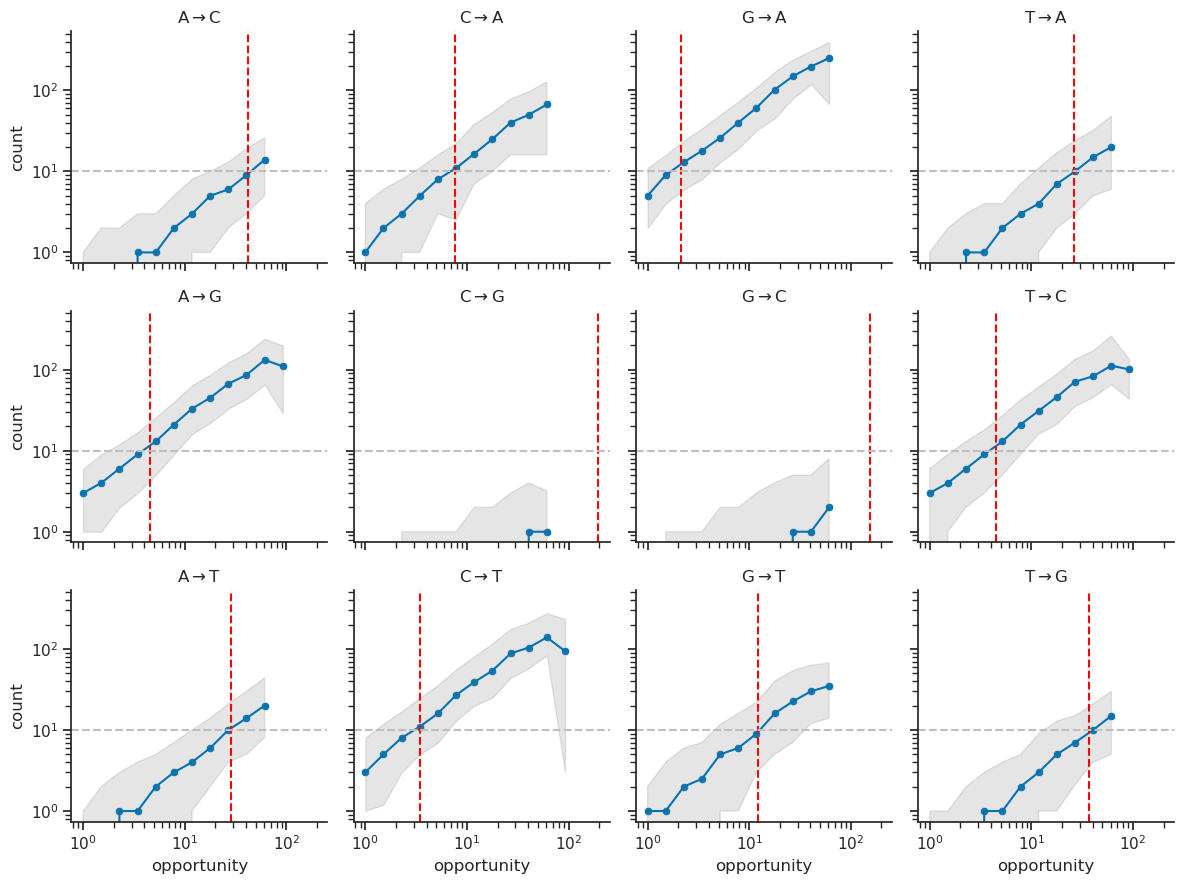

In [9]:
# Add a column that bins rows by evolutionary opportunity, defining bin edges in log space
bin_mins = np.logspace(0, 2.5, num=15)
labels = list(map(float, bin_mins[:-1]))
counts_df['evo_opp_bin'] = pd.cut(counts_df['evo_opp'], bins=bin_mins, include_lowest=True, labels=labels)
counts_df['evo_opp_bin'] = counts_df['evo_opp_bin'].astype(float)

# Compute summary stats of rates in bins of evo opp
metric = 'actual_count'
data = (
    counts_df[counts_df['mut_class'] == 'synonymous']
    .groupby(['mut_type', 'evo_opp_bin'], as_index=False)
    .agg(
        lower=(metric, lambda x: np.percentile(x, 10)),
        upper=(metric, lambda x: np.percentile(x, 90)),
        median=(metric, 'median'),
        nmuts=(metric, 'size')
    )
    .query('nmuts > 20')
)

# Plot summary stats for each mutation type
(fig, axs) = plt.subplots(ncols=4, nrows=3, figsize=[12,9], sharex=True, sharey=True)
axs = axs.reshape(-1, order='F')
for i, (mut_type, mut_type_data) in enumerate(data.groupby('mut_type')):

    # Plot a line showing the median as a function of evolutionary opportunity bin and
    # shaded regions showing the 10th and 90th percentiles
    sns.scatterplot(x='evo_opp_bin', y='median', data=mut_type_data, ax=axs[i])
    sns.lineplot(x='evo_opp_bin', y='median', data=mut_type_data, ax=axs[i])
    axs[i].fill_between(
        mut_type_data['evo_opp_bin'],
        mut_type_data['lower'],
        mut_type_data['upper'],
        alpha=0.2, color='gray'
    )

    # Plot evo_opp threshold computed from genome-wide data
    evo_opp_threshold = evo_opp_thresholds[
        evo_opp_thresholds['mut_type'] == mut_type
    ]['evo_opp_threshold'].values[0]
    axs[i].axvline(evo_opp_threshold, ls='--', color='red')
    axs[i].axhline(10, ls='--', color='0.75')
    mut_type_arrow = mut_type[0] + '$\\to$' + mut_type[1]
    axs[i].set(
        title=mut_type_arrow, xlabel='opportunity', ylabel='count',
        xscale='log', yscale='log'
    )

plt.tight_layout()
sns.despine()
plt.show()

Plot evolutionary opporunity vs. rate for individual mutation types. For each mutation, show the evolutionary-opportunity threshold from above (vertical red line) and the corresponding lower limit of detection for estimating site-specific rates (horizontal red line).

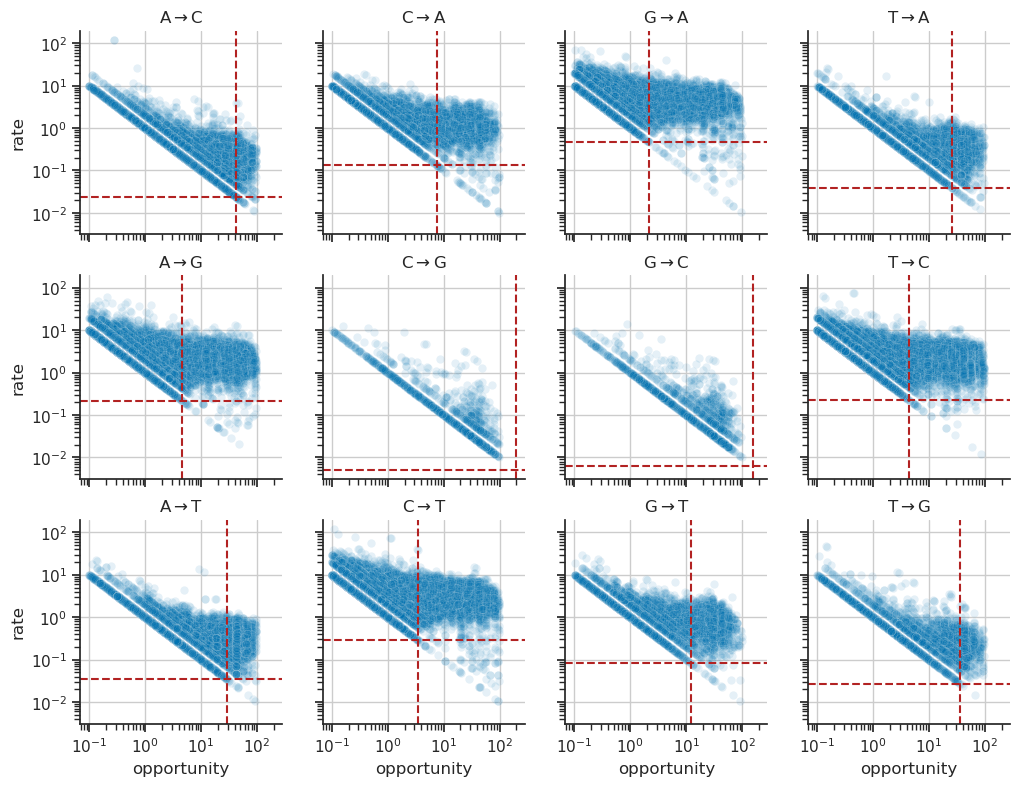

In [10]:
data = counts_df[
    (counts_df['evo_opp'] > genome_wide_evo_opp_threshold) &
    (counts_df['mut_class'] == 'synonymous')
]

(fig, axs) = plt.subplots(ncols=4, nrows=3, figsize=[12,9], sharex=True, sharey=True)
axs = axs.reshape(-1, order='F')
for i, (mut_type, mut_type_data) in enumerate(data.groupby('mut_type')):

    # Plot scatter
    sns.scatterplot(x='evo_opp', y='rate', data=mut_type_data, alpha=0.1, ax=axs[i])

    # Plot evo_opp threshold computed from genome-wide data
    evo_opp_threshold = evo_opp_thresholds[
        evo_opp_thresholds['mut_type'] == mut_type
    ]['evo_opp_threshold'].values[0]
    axs[i].axvline(evo_opp_threshold, ls='--', color='firebrick')
    axs[i].axhline(1/evo_opp_threshold, ls='--', color='firebrick')
    mut_type_arrow = mut_type[0] + '$\\to$' + mut_type[1]
    axs[i].set(xscale='log', yscale='log', title=mut_type_arrow, xlabel='opportunity')
    axs[i].grid()

sns.despine()
plt.show()

## Compute site-specific mutation rates

Make a dataframe of site-specific mutation rates. Focus on mutations with evolutionary opporunities above the thresholds defined above. Then, clip rates at a lower bound of 1 / evo_opp_threshold (this is the lower limit of detection for a given threshold).

In [11]:
# Compute rates
rates_df = (
    counts_df
    # remove data at the first and last sites in each segment, since they doesn't have a full 3mer motif
    .assign(max_site = lambda x: x.groupby(['subtype', 'segment'])['site'].transform('max'))
    .query('1 < site < max_site')
    # only analyze mutations with sufficient evolutionary opportunities
    .merge(evo_opp_thresholds[['mut_type', 'evo_opp_threshold']])
    .query('evo_opp >= evo_opp_threshold')
    # clip rates at lower limit of detection
    .assign(unclipped_rate = lambda x: x['rate'])
    .assign(min_rate = lambda x: 1 / x['evo_opp_threshold'])
    .assign(rate = lambda x: x[['min_rate', 'rate']].max(axis=1))
)

# Save the rates to a file
rates_df.to_csv('../results/site_specific_mutation_rates.csv', index=False)
rates_df.head()

,site,nt_mut,wt_nt,mut_nt,gene,codon_position,codon_site,wt_codon,mut_codon,wt_aa,mut_aa,aa_mut,motif,actual_count,branch_length,syn_branch_length,mut_class,mut_type,subtype,segment,segment_subtype,segment_length,host,evo_opp,rate,exclude_from_mut_rate_analysis,evo_opp_bin,max_site,evo_opp_threshold,unclipped_rate,min_rate
9,1274,A1274C,A,C,HA,2,425,AAT,ACT,N,T,N425T,AAT,0,135920,83918,nonsynonymous,AC,H1,HA,HA_H1,1698,all,49.421673,0.023638,False,40.4709,1700,42.3053,0.000000,0.023638
15,576,A576C,A,C,NP,3,192,GAA,GAC,E,D,E192D,AAC,3,89829,71934,nonsynonymous,AC,all,NP,NP_all,1494,all,48.148594,0.062307,False,40.4709,1496,42.3053,0.062307,0.023638
21,575,A575C,A,C,NP,2,192,GAA,GCA,E,A,E192A,GAA,0,110037,88094,nonsynonymous,AC,all,NP,NP_all,1494,all,58.965194,0.023638,False,40.4709,1496,42.3053,0.000000,0.023638
109,594,A594C,A,C,PA,3,198,GAA,GAC,E,D,E198D,AAG,1,172514,119714,nonsynonymous,AC,all,PA,PA_all,2148,human,55.732775,0.023638,True,40.4709,2150,42.3053,0.017943,0.023638
115,571,A571C,A,C,NP,1,191,ATG,CTG,M,L,M191L,GAT,2,113070,90727,nonsynonymous,AC,all,NP,NP_all,1494,all,60.727577,0.032934,False,40.4709,1496,42.3053,0.032934,0.023638
